# RiMEA 12b: Length of a Bottleneck

This notebook demonstrates the current public implementation of RiMEA Test 12b. We load one base bottleneck scenario, clone it into a short and a long bottleneck variant, run both variants across multiple seeds, and compare the evacuation times.

The expected qualitative result is simple: for the same bottleneck width, the **longer bottleneck should evacuate more slowly**.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pedpy

from core.scenario import load_scenario, run_scenario



In [2]:
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "#f7f7f5",
        "axes.edgecolor": "#3a3a3a",
        "axes.labelcolor": "#1d1d1d",
        "axes.titleweight": "bold",
        "font.size": 11,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
    }
)

VARIANT_COLORS = {
    0.2: "#2563EB",
    5.0: "#D97706",
}


## Load the Base Scenario

The scenario directory contains the short bottleneck geometry from the current public test implementation. The notebook deep-copies the raw data before creating the long bottleneck variant, so each run stays isolated.


In [3]:
SCENARIO_DIR = Path("scenarios") / "rimea-12b-bottleneck-length"
base_scenario = load_scenario(str(SCENARIO_DIR))
print(base_scenario.summary())


Scenario: /Users/chraibi/workspace/PedestrianDynamics/Web-Based-Jupedsim-issues/scripts/scenarios/rimea-12b-bottleneck-length
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      600s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         0
  Journeys:      1
  Agents:        ~100
  Journey elems: 2
  Route:         1 distribution, 0 checkpoint, 1 exit
  Sequence:      jps-distributions_0 -> jps-exits_0
    jps-distributions_0: 100 agents


## Helper Functions

We keep the bottleneck width fixed at `1.0 m` and only vary its length. A vertical measurement line at the bottleneck entrance is included in the trajectory panels to make the geometry easier to read.


In [4]:
def make_geometry(length: float) -> str:
    right_x = 10.0 + float(length)
    room2_right = right_x + 10.0
    return (
        f"POLYGON ((0 0, 10 0, 10 4.5, {right_x:.1f} 4.5, "
        f"{right_x:.1f} 0, {room2_right:.1f} 0, {room2_right:.1f} 10, {right_x:.1f} 10, "
        f"{right_x:.1f} 5.5, 10 5.5, 10 10, 0 10, 0 0))"
    )


def make_exit(length: float) -> dict:
    right_x = 10.0 + float(length)
    room2_right = right_x + 10.0
    return {
        "jps-exits_0": {
            "type": "polygon",
            "coordinates": [
                [room2_right - 2.2, 0],
                [room2_right, 0],
                [room2_right, 10],
                [room2_right - 2.2, 10],
                [room2_right - 2.2, 0],
            ],
            "enable_throughput_throttling": False,
            "max_throughput": 0,
        }
    }


def measurement_line() -> pedpy.MeasurementLine:
    return pedpy.MeasurementLine([(10.0, 4.5), (10.0, 5.5)])


def run_length_variant(base, length: float, seeds: list[int], demo_seed: int = 42) -> dict:
    scenario = base.copy(
        source_path=f"bottleneck-length-{length:.1f}m",
        walkable_area_wkt=make_geometry(length),
    )
    scenario.raw["exits"] = make_exit(length)

    demo_result = run_scenario(scenario, seed=demo_seed)
    trajectory = pedpy.TrajectoryData(
        demo_result.trajectory_dataframe()[["id", "frame", "x", "y"]].copy(),
        frame_rate=demo_result.frame_rate,
    )
    demo_metrics = dict(demo_result.metrics)
    demo_result.cleanup()

    evac_times = []
    for seed in seeds:
        result = run_scenario(scenario, seed=seed)
        evac_times.append(result.evacuation_time)
        result.cleanup()

    return {
        "length": float(length),
        "scenario": scenario,
        "line": measurement_line(),
        "walkable_area": pedpy.WalkableArea(scenario.walkable_polygon),
        "trajectory": trajectory,
        "demo_metrics": demo_metrics,
        "evac_times": np.array(evac_times, dtype=float),
    }


## Run the Bottleneck-Length Sweep

The trajectory panels below use one deterministic seed for visualization. The evacuation-time comparison uses several seeds so the short-vs-long difference is less sensitive to one random realization.


In [5]:
%%capture
LENGTHS = [0.2, 5.0]
SEEDS = [40, 41, 42]

runs = [run_length_variant(base_scenario, length, seeds=SEEDS, demo_seed=42) for length in LENGTHS]
summary_rows = [
    {
        "length_m": run["length"],
        "demo_evacuation_time_s": round(run["demo_metrics"]["evacuation_time"], 2),
        "mean_evacuation_time_s": round(run["evac_times"].mean(), 2),
        "std_s": round(run["evac_times"].std(ddof=1), 2),
    }
    for run in runs
]
summary_rows


## Plot Geometry and Trajectories

Each panel shows the room geometry, the bottleneck entrance line, and one deterministic trajectory set. The long bottleneck should visibly keep agents constrained for longer before they spread into room 2.


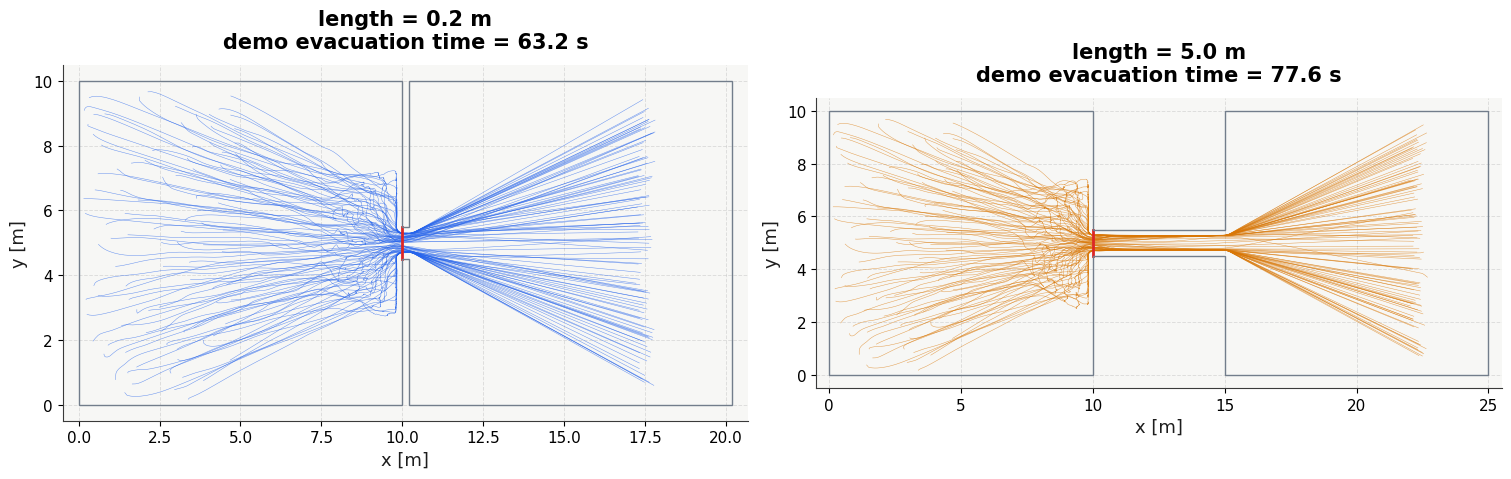

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

for ax, run in zip(axes, runs):
    color = VARIANT_COLORS[run["length"]]
    pedpy.plot_measurement_setup(
        traj=run["trajectory"],
        walkable_area=run["walkable_area"],
        measurement_lines=[run["line"]],
        axes=ax,
        traj_alpha=0.7,
        traj_width=0.35,
        ml_width=2.0,
        ml_alpha=0.25,
        traj_color=color,
        ml_color="#DC2626",
    ).set_aspect("equal")
    ax.set_title(
        f"length = {run['length']:.1f} m\n"
        f"demo evacuation time = {run['demo_metrics']['evacuation_time']:.1f} s",
        pad=12,
    )
    room2_right = 20.2 if run["length"] < 1 else 25.0
    ax.set_xlim(-0.5, room2_right + 0.5)
    ax.set_ylim(-0.5, 10.5)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.grid(True, linestyle="--", linewidth=0.7, alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()


## Compare Evacuation Times

The bars show the mean evacuation time across the chosen seeds, with one standard deviation as the error bar. The long bottleneck should sit clearly above the short one.


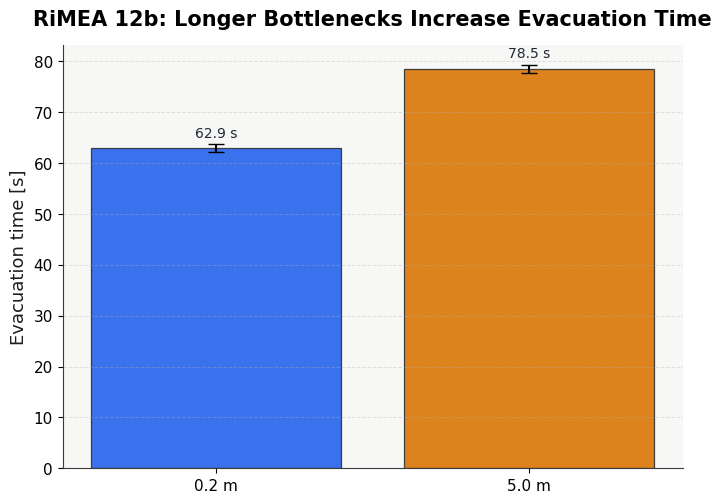

length=0.2 m -> mean=62.94s, std=0.76s, samples=[63.75 62.25 62.81]
length=5.0 m -> mean=78.51s, std=0.77s, samples=[79.39 78.19 77.96]


In [7]:
lengths = np.array([run["length"] for run in runs], dtype=float)
means = np.array([run["evac_times"].mean() for run in runs], dtype=float)
stds = np.array([run["evac_times"].std(ddof=1) for run in runs], dtype=float)

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.bar(
    ["0.2 m", "5.0 m"],
    means,
    yerr=stds,
    color=[VARIANT_COLORS[length] for length in lengths],
    alpha=0.9,
    capsize=6,
    edgecolor="#2f2f2f",
    linewidth=0.9,
)

for bar, mean in zip(bars, means):
    ax.annotate(
        f"{mean:.1f} s",
        (bar.get_x() + bar.get_width() / 2.0, mean),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        color="#1f2937",
        fontsize=10,
    )

ax.set_title("RiMEA 12b: Longer Bottlenecks Increase Evacuation Time", pad=14)
ax.set_ylabel("Evacuation time [s]")
ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()

for run in runs:
    print(
        f"length={run['length']:.1f} m -> mean={run['evac_times'].mean():.2f}s, "
        f"std={run['evac_times'].std(ddof=1):.2f}s, samples={np.round(run['evac_times'], 2)}"
    )
